In [2]:
#imported from Pranav Sanghavi's notebook 
import glob 
import os
import time
import h5py
import matplotlib.pylab as plt
import numpy as np
import numpy.ma as ma
from matplotlib.offsetbox import AnchoredText
from matplotlib.pylab import colorbar 
from skrf import Network, Frequency
from platform import python_version
import math
import psutil
import matplotlib.cm as cm
from scipy.optimize import leastsq
from scipy.optimize import curve_fit

#importing for Will's function 
from scipy import interpolate
import datetime
from scipy.signal import square
from scipy.stats import pearsonr
import pandas
import time_utils as tu
from mpl_toolkits.axes_grid1 import make_axes_locatable


style = 'fast'
tick_dir = 'in'
plt.style.use(style)
plt.rcParams['xtick.direction'] = tick_dir
plt.rcParams['ytick.direction'] = tick_dir
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['font.size'] = 15
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif"})

###################################################################################
# Analog chain labels
###################################################################################

#pathtoacfile = "/home/observer/tone_jupyter/anachainz.csv"
#ac = np.genfromtxt(pathtoacfile, delimiter=",", names=True,
#                   dtype=(int, int, 'U5', 'U5', int, 'U2', int))
#inputs = ac['feed']

def get_beam_fwhm(d=6.0, nu=600):
    fwhm = constants.c/(nu*1e6)/d   # lambda/D
    return np.rad2deg(fwhm * 1.22)

def gaussian(x, a, mean, sigma):
    val = a * np.exp(-(x - mean)**2 / sigma**2)
    return val

def scale_zero_one(x):
    return (x - x.min())/(x.max() - x.min())

def seconds_to_degrees(seconds, declination=22.0145):
    """
        This function converts seconds to degrees of sky motion at a latitude 
        default TONE latitude -- default for crab.
    """
    return seconds * np.cos(np.deg2rad(declination)) / 240

def read_corr_mode_h5(file_path, f_start=None, f_stop=None):
    """
        This function reads all hdf5 files.
    """
    class correlator_data:
        def __init__(self, vis, time, sat, index_map):
            self.vis = vis
            self.time = time
            self.sat = sat
            self.freq = index_map["freq"][:]
            self.prod = index_map['prod'][:]
    files = glob.glob(file_path + "*[!.lock]")
    files.sort()
    
    #grab different sets of files.  
    if f_start is not None:
        if f_stop is not None:
            files = files[f_start:f_stop]
        else:
            files = files[f_start:]
    if f_start is None:
        if f_stop is not None:
            files = files[:f_stop]

    try:
        t = 0
        for x in files:
            print(f"Reading File: {x}")
            f = h5py.File(x, "r")
            index_map = f['index_map']
            if(t == 0):
                vis = f['vis'][:]
                time = index_map['time'][:]
                sat = f['sat'][:]
                print("Appended vis data and time stream from %s" % (x))
                t = t + 1
            else:
                time = np.append(time, index_map['time'][:])
                vis = np.append(vis, f['vis'][:], axis=0)
                sat = np.append(sat, f['sat'][:], axis=0)
                print("Appended vis data and time stream from %s" % (x))
        
        return correlator_data(
            vis,
            time,
            sat,
            index_map
        )
    finally:
        print("Done!!!!!!!")

def get_mag_phase(corr_dat):
    """
        This function returns magnitude and phase in degrees of correlations.
    """
    return np.absolute(corr_dat), np.rad2deg(np.angle(corr_dat))

def plot_waterfall_corr_data(data, corr_indices):
    """
        This function plots waterfall across 1024 frequency channels.
        Frequency range: 400-800MHz
    """
    fig=plt.figure(figsize=(20,20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for i,auto in enumerate(corr_indices):
        ax=plt.subplot(dim1, dim2, i + 1)
        wfall = data[:, :, auto] # auto -> corr index 
        im=plt.imshow(wfall, vmin = np.nanpercentile(wfall,5), vmax =np.nanpercentile(wfall,95), cmap='gnuplot2', aspect='auto')
        plt.xlabel("freq index")
        plt.ylabel("time index")
        plt.title(f"corr {corr_data.prod[auto]}")
        divider=make_axes_locatable(ax)
        cax=divider.append_axes("right", size="5%", pad=0.05)
        cbar=fig.colorbar(im,cax=cax)
        cbar.set_label('Power [$ADU^2$]')
    plt.tight_layout()
    
def plot_freq_channel_corr_data(pow_mag, freq_index, freq, corr_indices):
    """
        This function plots phase for a given frequency index for given time window.
    """
    plt.figure(figsize=(20, 20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for index, corr_index in enumerate(corr_indices):
            plt.subplot(dim1, dim2, index + 1)
            plt.title(f"Corr: {corr_data.prod[corr_index]}")
            plt.plot(pow_mag[:, freq_index, corr_index])
    plt.suptitle(f"Frequency {freq} MHz")
    plt.tight_layout()
    
def plot_phase_corr_data(pow_phase, corr_indices, t_ind_arr):
    """
        This function plots phase for a given time index across frequency range of 400-800MHz.
    """
    for i, t_index in enumerate(t_ind_arr):
        fig= plt.figure(figsize=(25, 10))
        dim1 = math.floor(math.sqrt(len(corr_indices)*len(t_ind_arr)))
        dim2 = math.ceil(len(corr_indices)*len(t_ind_arr)/dim1)
        for index, corr_index in enumerate(corr_indices):
                ax = plt.subplot(dim2, dim1, i + 1)
                ax.plot(pow_phase[t_index,:, corr_index], c=colorsarr[300], label=f'time index {t_index}')
                ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
                plt.xlabel(f"frequency index")
                plt.ylabel(f"phase (degrees)")
                plt.title(f"Corr: {corr_data.prod[corr_index]}")
                #plt.suptitle(f"Correlated noise phase")
        plt.tight_layout()

def chunk_lists_(data_):
    """
        This function makes sublists of time indices of individual ON/OFF pulses.
        Returns list of lists
    """

    consecutive_list = []

    for chunks in range(len(data_)):
        try:
            if data_[chunks + 1] - data_[chunks] == 1:
                
                #check if index is already in list:
                if data_[chunks] not in consecutive_list:
                    consecutive_list.append(data_[chunks])
                #add last index too
                consecutive_list.append(data_[chunks + 1])

            else:
                yield consecutive_list
                consecutive_list = []
                
        except Exception:
            pass
        
    yield consecutive_list
    
#fitting function -- exponential decay
#def fit_(x, A, k):
#    return A * np.exp(-k * x)  

#fitting function 
def fit_(x, A, k):
    return A/(x+k)     

In [ ]:
#reading digital gains (.h5 file)
f = h5py.File("/Volumes/X10 Pro/yale_Apr25/digital_gains/20250412T191307Z_WVUc52_digitalgain/00000056.h5","r")

#plotting digital gains 
print(list(f.attrs))
print(f.attrs['acquisition_name'])
print(f.attrs['archive_version'])
print(f.attrs['collection_server'])
print(f.attrs['git_version_tag'])
print(f.attrs['instrument_name'])
print(f.attrs['notes'])
print(f.attrs['system_user'])
print(f.attrs['type'])
print(f.attrs['version'])

print(list(f.items()))
print((f['compute_time']))
print((f['index_map']))
print((f['gain_coeff']))
print((f['gain_exp'])) 

inputs = (f['index_map']['input'][:])
frqs = f['index_map']['freq'][:]
gaincoeff = f['gain_coeff'][()]
gainexp = f['gain_exp'][()]
gain = gaincoeff.real*np.exp2(gainexp)

plt.figure(figsize=[16,18])
print(f"Calculating digital gains of the channels...")
i = 0
for i in np.arange(0,4,1):  
    plt.subplot(8,2,i+1)
    #Digital gain of every channel
    plt.scatter(frqs['centre'], gain[0][:,i]) # i referes to input channel (total 16 ch on iceboard); 
    #plt.title( " %s and gain_exp = %s and rms %s for rms i/p %s" %(inputs[i], gainexp[:,i], rms[i][2], rms[i][0][2]))
    plt.title( " %s " %(inputs[i]))
plt.tight_layout()


In [70]:
def beam_amp_recovery(freq_arr):
    """Function to plot beam amplitude recovery (%):
    
    Parameters
    ----------
    
    avgs: averages of ON data points of individual correlator channels 
    avgs_off: averages of OFF data points of individual correlator channels
    stds: standard deviations of ON data points of individual correlator channels
    var: variances of ON data points of individual correlator channels
    var_off: variances of OFF data points of individual correlator channels
    """
    
    colorsarr=cm.gnuplot2(np.linspace(0,1,1024))
    fig = plt.figure(figsize=[30,30])
    for index,f_ind in enumerate(freq_arr):
        
        avgs=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/stats_individual_pulses/means_fbin{}.npz".format(f_ind))
        avgs_off=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/stats_individual_pulses/means_off_fbin{}.npz".format(f_ind))
        stds=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/stats_individual_pulses/stds_fbin{}.npz".format(f_ind))
        var=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/stats_individual_pulses/var_fbin{}.npz".format(f_ind))
        var_off=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/stats_individual_pulses/var_off_fbin{}.npz".format(f_ind))

        """stats from saved files -- N 65536 (steps of 5 degrees) (range -50 t0 130)
        autos and crosses means, std dev and variances lists -- correlator data 
        
        Parameters
        ----------

        autos_0x0 -- <VV*>t,ON
        autos_0x0_off -- <VV*>t,OFF
        crosses_0x1 -- <VtVref*>ON
        autos_1x1 -- <VV*>ref,ON 
        autos_1x1_off -- <VV*>ref,OFF (which is 0 in this case) 
        """
        
        #autos00 = [avgs['avgs50n'][0], avgs['avgs45n'][0], avgs['avgs40n'][0], avgs['avgs35n'][0], avgs['avgs30n'][0], avgs['avgs25n'][0], avgs['avgs20n'][0], avgs['avgs15n'][0], avgs['avgs10n'][0], avgs['avgs5n'][0], avgs['avgs0'][0], avgs['avgs5p'][0], avgs['avgs10p'][0], avgs['avgs15p'][0], avgs['avgs20p'][0], avgs['avgs25p'][0], avgs['avgs30p'][0], avgs['avgs35p'][0], avgs['avgs40p'][0], avgs['avgs45p'][0], avgs['avgs50p'][0], avgs['avgs55p'][0], avgs['avgs60p'][0], avgs['avgs65p'][0], avgs['avgs70p'][0], avgs['avgs75p'][0], avgs['avgs80p'][0], avgs['avgs85p'][0], avgs['avgs90p'][0], avgs['avgs95p'][0], avgs['avgs100p'][0], avgs['avgs105p'][0], avgs['avgs110p'][0], avgs['avgs115p'][0], avgs['avgs120p'][0], avgs['avgs125p'][0], avgs['avgs130p'][0], avgs['avgs135p'][0]]
        #autos11 = [avgs['avgs50n'][2], avgs['avgs45n'][2], avgs['avgs40n'][2], avgs['avgs35n'][2], avgs['avgs30n'][2], avgs['avgs25n'][2], avgs['avgs20n'][2], avgs['avgs15n'][2], avgs['avgs10n'][2], avgs['avgs5n'][2], avgs['avgs0'][2], avgs['avgs5p'][2], avgs['avgs10p'][2], avgs['avgs15p'][2], avgs['avgs20p'][2], avgs['avgs25p'][2], avgs['avgs30p'][2], avgs['avgs35p'][2], avgs['avgs40p'][2], avgs['avgs45p'][2], avgs['avgs50p'][2], avgs['avgs55p'][2], avgs['avgs60p'][2], avgs['avgs65p'][2], avgs['avgs70p'][2], avgs['avgs75p'][2], avgs['avgs80p'][2], avgs['avgs85p'][2], avgs['avgs90p'][2], avgs['avgs95p'][2], avgs['avgs100p'][2], avgs['avgs105p'][2], avgs['avgs110p'][2], avgs['avgs115p'][2], avgs['avgs120p'][2], avgs['avgs125p'][2], avgs['avgs130p'][2], avgs['avgs135p'][2]]
        #crosses01 = [avgs['avgs50n'][1], avgs['avgs45n'][1], avgs['avgs40n'][1], avgs['avgs35n'][1], avgs['avgs30n'][1], avgs['avgs25n'][1], avgs['avgs20n'][1], avgs['avgs15n'][1], avgs['avgs10n'][1], avgs['avgs5n'][1], avgs['avgs0'][1], avgs['avgs5p'][1], avgs['avgs10p'][1], avgs['avgs15p'][1], avgs['avgs20p'][1], avgs['avgs25p'][1], avgs['avgs30p'][1], avgs['avgs35p'][1], avgs['avgs40p'][1], avgs['avgs45p'][1], avgs['avgs50p'][1], avgs['avgs55p'][1], avgs['avgs60p'][1], avgs['avgs65p'][1], avgs['avgs70p'][1], avgs['avgs75p'][1], avgs['avgs80p'][1], avgs['avgs85p'][1], avgs['avgs90p'][1], avgs['avgs95p'][1], avgs['avgs100p'][1], avgs['avgs105p'][1], avgs['avgs110p'][1], avgs['avgs115p'][1], avgs['avgs120p'][1], avgs['avgs125p'][1], avgs['avgs130p'][1], avgs['avgs135p'][1]]
        #var_auto00 = [var['var50n'][0], var['var45n'][0], var['var40n'][0], var['var35n'][0], var['var30n'][0], var['var25n'][0], var['var20n'][0], var['var15n'][0], var['var10n'][0], var['var5n'][0], var['var0'][0], var['var5p'][0], var['var10p'][0], var['var15p'][0], var['var20p'][0], var['var25p'][0], var['var30p'][0], var['var35p'][0], var['var40p'][0], var['var45p'][0], var['var50p'][0], var['var55p'][0], var['var60p'][0], var['var65p'][0], var['var70p'][0], var['var75p'][0], var['var80p'][0], var['var85p'][0], var['var90p'][0], var['var95p'][0], var['var100p'][0], var['var105p'][0], var['var110p'][0], var['var115p'][0], var['var120p'][0], var['var125p'][0], var['var130p'][0], var['var135p'][0]]
        #var_auto11 = [var['var50n'][2], var['var45n'][2], var['var40n'][2], var['var35n'][2], var['var30n'][2], var['var25n'][2], var['var20n'][2], var['var15n'][2], var['var10n'][2], var['var5n'][2], var['var0'][2], var['var5p'][2], var['var10p'][2], var['var15p'][2], var['var20p'][2], var['var25p'][2], var['var30p'][2], var['var35p'][2], var['var40p'][2], var['var45p'][2], var['var50p'][2], var['var55p'][2], var['var60p'][2], var['var65p'][2], var['var70p'][2], var['var75p'][2], var['var80p'][2], var['var85p'][2], var['var90p'][2], var['var95p'][2], var['var100p'][2], var['var105p'][2], var['var110p'][2], var['var115p'][2], var['var120p'][2], var['var125p'][2], var['var130p'][2], var['var135p'][2]]
        #stddev_cross01 = [stds['stds50n'][1], stds['stds45n'][1], stds['stds40n'][1], stds['stds35n'][1], stds['stds30n'][1], stds['stds25n'][1], stds['stds20n'][1], stds['stds15n'][1], stds['stds10n'][1], stds['stds5n'][1], stds['stds0'][1], stds['stds5p'][1], stds['stds10p'][1], stds['stds15p'][1], stds['stds20p'][1], stds['stds25p'][1], stds['stds30p'][1], stds['stds35p'][1], stds['stds40p'][1], stds['stds45p'][1], stds['stds50p'][1], stds['stds55p'][1], stds['stds60p'][1], stds['stds65p'][1], stds['stds70p'][1], stds['stds75p'][1], stds['stds80p'][1], stds['stds85p'][1], stds['stds90p'][1], stds['stds95p'][1], stds['stds100p'][1], stds['stds105p'][1], stds['stds110p'][1], stds['stds115p'][1], stds['stds120p'][1], stds['stds125p'][1], stds['stds130p'][1],stds['stds135p'][1]]
        
        autos00 = [avgs['avgs10n'][0], avgs['avgs5n'][0], avgs['avgs0'][0], avgs['avgs5p'][0], avgs['avgs10p'][0]]
        autos11 = [avgs['avgs10n'][2], avgs['avgs5n'][2], avgs['avgs0'][2], avgs['avgs5p'][2], avgs['avgs10p'][2]]
        crosses01 = [avgs['avgs10n'][1], avgs['avgs5n'][1], avgs['avgs0'][1], avgs['avgs5p'][1], avgs['avgs10p'][1]]
        var_auto00 = [var['var10n'][0], var['var5n'][0], var['var0'][0], var['var5p'][0], var['var10p'][0]]
        var_auto11 = [var['var10n'][2], var['var5n'][2], var['var0'][2], var['var5p'][2], var['var10p'][2]]
        stddev_cross01 = [stds['stds10n'][1], stds['stds5n'][1], stds['stds0'][1], stds['stds5p'][1], stds['stds10p'][1]]

        autos_0x0 = []
        autos_1x1 = []
        crosses_0x1 = []
        var_auto0x0 = []
        var_auto1x1 = []
        stddev_cross = []

        for i, array in enumerate(autos00):
            for j in range(len(autos00[i])):
                autos_0x0.append(autos00[i][j])
                autos_1x1.append(autos11[i][j])
                crosses_0x1.append(crosses01[i][j])
                var_auto0x0.append(var_auto00[i][j])
                var_auto1x1.append(var_auto11[i][j])
                stddev_cross.append(stddev_cross01[i][j])
        
        #autos00_off = [avgs_off['avgs_off50n'][0], avgs_off['avgs_off45n'][0], avgs_off['avgs_off40n'][0], avgs_off['avgs_off35n'][0], avgs_off['avgs_off30n'][0], avgs_off['avgs_off25n'][0], avgs_off['avgs_off20n'][0], avgs_off['avgs_off15n'][0], avgs_off['avgs_off10n'][0], avgs_off['avgs_off5n'][0], avgs_off['avgs_off0'][0], avgs_off['avgs_off5p'][0], avgs_off['avgs_off10p'][0], avgs_off['avgs_off15p'][0], avgs_off['avgs_off20p'][0], avgs_off['avgs_off25p'][0], avgs_off['avgs_off30p'][0], avgs_off['avgs_off35p'][0], avgs_off['avgs_off40p'][0], avgs_off['avgs_off45p'][0], avgs_off['avgs_off50p'][0], avgs_off['avgs_off55p'][0], avgs_off['avgs_off60p'][0], avgs_off['avgs_off65p'][0], avgs_off['avgs_off70p'][0], avgs_off['avgs_off75p'][0], avgs_off['avgs_off80p'][0], avgs_off['avgs_off85p'][0], avgs_off['avgs_off90p'][0], avgs_off['avgs_off95p'][0], avgs_off['avgs_off100p'][0], avgs_off['avgs_off105p'][0], avgs_off['avgs_off110p'][0], avgs_off['avgs_off115p'][0], avgs_off['avgs_off120p'][0], avgs_off['avgs_off125p'][0], avgs_off['avgs_off130p'][0], avgs_off['avgs_off135p'][0]]
        autos00_off = [avgs_off['avgs_off10n'][0], avgs_off['avgs_off5n'][0], avgs_off['avgs_off0'][0], avgs_off['avgs_off5p'][0], avgs_off['avgs_off10p'][0]]
        autos_0x0_off = []

        for i, array in enumerate(autos00_off):
            for j in range(len(autos00_off[i])):
                autos_0x0_off.append(autos00_off[i][j])

        #var_auto00_off = [var_off['var_off50n'][0], var_off['var_off45n'][0], var_off['var_off40n'][0], var_off['var_off35n'][0], var_off['var_off30n'][0], var_off['var_off25n'][0], var_off['var_off20n'][0], var_off['var_off15n'][0], var_off['var_off10n'][0], var_off['var_off5n'][0], var_off['var_off0'][0], var_off['var_off5p'][0], var_off['var_off10p'][0], var_off['var_off15p'][0], var_off['var_off20p'][0], var_off['var_off25p'][0], var_off['var_off30p'][0], var_off['var_off35p'][0], var_off['var_off40p'][0], var_off['var_off45p'][0], var_off['var_off50p'][0], var_off['var_off55p'][0], var_off['var_off60p'][0], var_off['var_off65p'][0], var_off['var_off70p'][0], var_off['var_off75p'][0], var_off['var_off80p'][0], var_off['var_off85p'][0], var_off['var_off90p'][0], var_off['var_off95p'][0], var_off['var_off100p'][0], var_off['var_off105p'][0], var_off['var_off110p'][0], var_off['var_off115p'][0], var_off['var_off120p'][0], var_off['var_off125p'][0], var_off['var_off130p'][0], var_off['var_off135p'][0]]
        var_auto00_off = [var_off['var_off10n'][0], var_off['var_off5n'][0], var_off['var_off0'][0], var_off['var_off5p'][0], var_off['var_off10p'][0]]
        var_auto0x0_off = []

        for i, array in enumerate(var_auto00_off):
            for j in range(len(var_auto00_off[i])):
                var_auto0x0_off.append(var_auto00_off[i][j])
        #making all "off" stats arrays equal length: 
        var_auto0x0_off=var_auto0x0_off[:len(autos_0x0_off)]
        
        
        freq=400+((1024-f_ind)*0.390625) 
        #print('Given frequency: {}MHz'.format(freq))

        # converting into numpy ndarray for arithmatic operations -- N 65536
        """
            autos_0x0 -- <VV*>t,ON and # autos_1x1 -- <VV*>ref,ON 
        """
        
        autos_0x0_arr=np.array(autos_0x0)
        autos_0x0= autos_0x0_arr[:len(autos_0x0_off)]
        crosses_0x1_arr=np.array(crosses_0x1)
        crosses_0x1=crosses_0x1_arr[:len(autos_0x0_off)]
        autos_1x1_arr=np.array(autos_1x1)
        autos_1x1=autos_1x1_arr[:len(autos_0x0_off)]
        autos_0x0_off_arr=np.array(autos_0x0_off)
        autos_0x0_off= autos_0x0_off_arr

        var_auto1x1_arr=np.array(var_auto1x1)
        var_auto1x1=var_auto1x1_arr[:len(autos_0x0_off)]
        var_auto0x0_arr=np.array(var_auto0x0)
        var_auto0x0=var_auto0x0_arr[:len(autos_0x0_off)]
        var_auto0x0_off_arr=np.array(var_auto0x0_off)
        var_auto0x0_off= var_auto0x0_off_arr
        
        stddev_cross_arr=np.array(stddev_cross)
        stddev_cross0x1= stddev_cross_arr[:len(autos_0x0_off)]

        # sqrt of total integration period -- N 65536
        stddev_cross0x1 = stddev_cross0x1/2 

        ## autos0x0 --  <VV*>t,ON - <VV*>t,OFF / <VV*>ref,ON - <VV*>ref,OFF -- N 65536 
        g_autos_0x0 = (autos_0x0 - autos_0x0_off) / autos_1x1

        ## error propagation equation -- to calculate variance and std dev of gauto0x0_2 -- N 65536 
        t11 = np.square(1/autos_1x1) 
        t21 = np.square(1/autos_1x1) 
        t31 = np.square((autos_0x0-autos_0x0_off)/(np.square(autos_1x1))) 

        t12=var_auto0x0 # var(on_index)
        t22=var_auto0x0_off # var(off_index) 
        t32=var_auto1x1 # var(on_index) 

        t1 = t11*t12
        t2 = t21*t22
        t3 = t31*t32

        var_gauto0x0= t1 + t2 + t3 
        stddev_gauto0x0=np.sqrt(var_gauto0x0)/2

        # error for crosses -- std/mean -- N 65536 
        err_crosses = []
        err_cross_percent = []
        for i in np.arange(0,np.size(stddev_cross0x1)):
            err = stddev_cross0x1[i]/crosses_0x1[i]
            err_crosses.append(err)
            err_percent = (stddev_cross0x1[i]/crosses_0x1[i])*100
            err_cross_percent.append(err_percent)

        # error for autos -- std/mean -- N 65536 
        err_autos = []
        err_auto_percent = []
        for i in np.arange(0,np.size(stddev_gauto0x0)):
            aerr = stddev_gauto0x0[i]/g_autos_0x0[i]
            err_autos.append(aerr)
            aerr_percent = (stddev_gauto0x0[i]/g_autos_0x0[i])*100
            err_auto_percent.append(aerr_percent)

        #gT= Scal/Tsys
        #Scal/Tsys=(Pon-Poff)/Poff
        g_T = (autos_0x0 - autos_0x0_off) / autos_0x0_off
        #print("total gain values are: {}".format(len(g_T)))
        #print('Telescopic gains are: {}'.format(g_T))

        ##dns simulations -- beam amp recovery in presence of noise 

        #Import a file -- loading saved data for (impact of noise) sims -- N 65536
        data=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/gain_sweep_10000.npz")
        #Assign the variables:
        gain_auto_quant= data['gain_auto_quant'] 
        gain_cross_quant= data['gain_cross_quant'] 
        gains= data['gains'] 
        ## Close the file:
        data.close()

        #Normalizing the data with gains -- N 65536
        int_time =4*16384 
        gain_auto_quant_std = (gain_auto_quant/(2*int_time*gains*gains)).std(axis=0)[:len(gains)]
        gain_cross_quant_std = (gain_cross_quant/(2*int_time*gains)).std(axis=0)[:len(gains)]
        gain_auto_qaunt_mean= (gain_auto_quant/(2*int_time*gains*gains)).mean(axis=0)[:len(gains)]
        gain_cross_quant_mean = (gain_cross_quant/(2*int_time*gains)).mean(axis=0)[:len(gains)]

        ##dns simulations -- beam amplitude recovery in presence of timing noise 

        fman=727e6 #select freq
        t_length=65536 # 4*16384
        inputpower=2**0 # this is 1
        iteration_space=np.arange(10000) # total 10000 realizations 
        jitter_space=np.hstack((np.array([0]),np.linspace(0.0e-9,1.4e-9,14))) # total 15 values 
        #jitter_space=np.hstack((np.array([0]),np.linspace(1.4e-9,2.1e-9,8))) # total 9 values
        gain_space=(np.linspace(0.05,1.2,15)**2.0) # total 30 values 

        #Import a file -- loading saved data for (imapact of timing jitter) sims -- N 65536
        dat=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/beam_amp_recovery_timing0-1.4ns_10000.npz")
        #Assign the variables:
        input_phase=dat['input_phase']
        q_sig_scaling=dat['q_sig_scaling']
        q_corr_scaling=dat['q_corr_scaling']
        nq_max_ind_auto=dat['nq_max_ind_auto']
        nq_max_mag_auto_on=dat['nq_max_mag_auto_on']
        nq_max_mag_auto_off=dat['nq_max_mag_auto_off']
        nq_max_ind_cross=dat['nq_max_ind_cross']
        nq_max_mag_cross_on=dat['nq_max_mag_cross_on']
        nq_max_mag_cross_off=dat['nq_max_mag_cross_off']
        q_max_ind_auto=dat['q_max_ind_auto']
        q_max_mag_auto_on=dat['q_max_mag_auto_on']
        q_max_mag_auto_off=dat['q_max_mag_auto_off']
        q_max_ind_cross=dat['q_max_ind_cross']
        q_max_mag_cross_on=dat['q_max_mag_cross_on']
        q_max_mag_cross_off=dat['q_max_mag_cross_off']
        #Close the file:
        dat.close()

        q_a_norm=np.zeros(q_max_mag_auto_on.shape) # normalization factor for autos 
        q_c_norm=np.zeros(q_max_mag_auto_on.shape) # normalization factor for crosses 
        for j in range(len(jitter_space)):
            q_a_norm[j,:,:]=(1.0/(2*(inputpower**2.0)*(q_corr_scaling[j,:,:]**2.0)*(t_length)*(np.outer((gain_space[:]**2.0),np.ones(len(iteration_space))))))
            q_c_norm[j,:,:]=(1.0/(2*(inputpower**2.0)*q_corr_scaling[j,:,:]*q_sig_scaling[j,:,:]*(t_length)*(np.outer((gain_space[:]**1.0),np.ones(len(iteration_space))))))

        # q_x -- error on autos; q_y -- error on crosses; q_z -- error on phase 
        q_x=100.0*np.nanstd((np.abs(q_a_norm*q_max_mag_auto_on[:,:,:])-np.abs(q_a_norm*q_max_mag_auto_off[:,:,:])),axis=2)/np.nanmean((np.abs(q_a_norm*q_max_mag_auto_on[:,:,:])-np.abs(q_a_norm*q_max_mag_auto_off[:,:,:])),axis=2)
        q_y=100.0*np.nanstd(np.abs(q_c_norm*q_max_mag_cross_on[:,:,:]),axis=2)/np.nanmean(np.abs(q_c_norm*q_max_mag_cross_on[:,:,:]),axis=2)
        q_z=100.0*np.nanstd(-np.angle(nq_max_mag_cross_on[:,:,:]),axis=2)/(2.0*np.pi)

        #print('jitter space is given as: {}'.format(jitter_space))

        #Plot of 10000 realizations used for DNS paper along with implementation results -- beam amplitude recovery (%)
        dim1 = math.floor(math.sqrt(len(freq_arr)))
        dim2 = math.ceil(len(freq_arr)/dim1)
        ax = plt.subplot(dim2,dim1,index+1)
        ax.plot(gain_space*gain_space,q_x[14,:],linestyle= 'dashdot',c=colorsarr[700],label='Autocorr-theo')
        ax.plot(gain_space*gain_space,q_y[14,:],linestyle= 'dashdot',c=colorsarr[400],label='Crosscorr-theo')
        ax.plot(g_T[29:44], err_cross_percent[29:44], 'x', c=colorsarr[500], label='Crosscorr-pract')
        ax.plot(g_T[29:44], err_auto_percent[29:44], 's', c=colorsarr[300], label='Autocorr-pract')
        plt.xlabel('$\hat{g_T}$', fontsize= 13) 
        plt.ylabel('Beam Amplitude Recovery [%]', fontsize= 13) 
        plt.axhline(y = 1, color = 'r', linestyle = '--', label= "1% threshold")
        #plt.axvline(x = 0.558, c=colorsarr[50], ymin=0.0, ymax=0.1, linestyle = '--')
        #plt.axvline(x = 0.665, c=colorsarr[50], ymin=0.0, ymax=0.1, linestyle = '--')
        
        #performing fit on beam amp recovery errors: 
        #bounds = ([0,0], [np.inf, np.inf])
        #initial_params_crosses = [0.2,0.1]
        #initial_params_autos = [1,0.001]
        bounds = ([0,0], [np.inf, np.inf])
        initial_params_crosses = [10,15]
        initial_params_autos = [1,0.001]
        popt_cross, pcov_cross = curve_fit(fit_, g_T[:], err_cross_percent[:], p0=initial_params_crosses, bounds=bounds, nan_policy='omit')
        popt_auto, pcov_auto = curve_fit(fit_, g_T[:], err_auto_percent[:], p0=initial_params_autos, bounds=bounds, nan_policy='omit')
    
        #Extracting fitted parameters:
        A_fit_cross, k_fit_cross = popt_cross
        A_fit_auto, k_fit_auto = popt_auto
        print(f"Fitted parameters for crosses: A = {A_fit_cross:.3f}, k = {k_fit_cross:.3f}")
        print(f"Fitted parameters for autos: A = {A_fit_auto:.3f}, k = {k_fit_auto:.3f}")
        x_fit = g_T[:]
        y_fit_cross = fit_(x_fit, *popt_cross)
        y_fit_auto = fit_(x_fit, *popt_auto)
        #ax.plot(x_fit, y_fit_cross,'*--',c=colorsarr[100], label="Fitted curve for crosses")
        #ax.plot(x_fit, y_fit_auto,'*--',c=colorsarr[200], label="Fitted curve for autos")
        
        plt.grid(True)
        ax.legend(fontsize= 13)
        plt.ylim(-2,20)
        plt.xlim(0.00025,1)
        #plt.suptitle("Main beam amplitude recovery", fontsize=40)
        plt.title(f"Freq bin {f_ind} ({freq} MHz) -- timing jitter {jitter_space[14]}ns", fontsize=15)
    plt.tight_layout()
    return pcov_cross


Fitted parameters for crosses: A = 0.565, k = 0.045
Fitted parameters for autos: A = 0.029, k = 0.002
Fitted parameters for crosses: A = 0.863, k = 0.089
Fitted parameters for autos: A = 0.646, k = 0.000
Fitted parameters for crosses: A = 0.923, k = 0.089
Fitted parameters for autos: A = 0.877, k = 0.000
Fitted parameters for crosses: A = 0.939, k = 0.082
Fitted parameters for autos: A = 0.659, k = 0.000
Fitted parameters for crosses: A = 0.400, k = 0.035
Fitted parameters for autos: A = 0.000, k = 0.785
Fitted parameters for crosses: A = 0.635, k = 0.052
Fitted parameters for autos: A = 0.704, k = 0.000


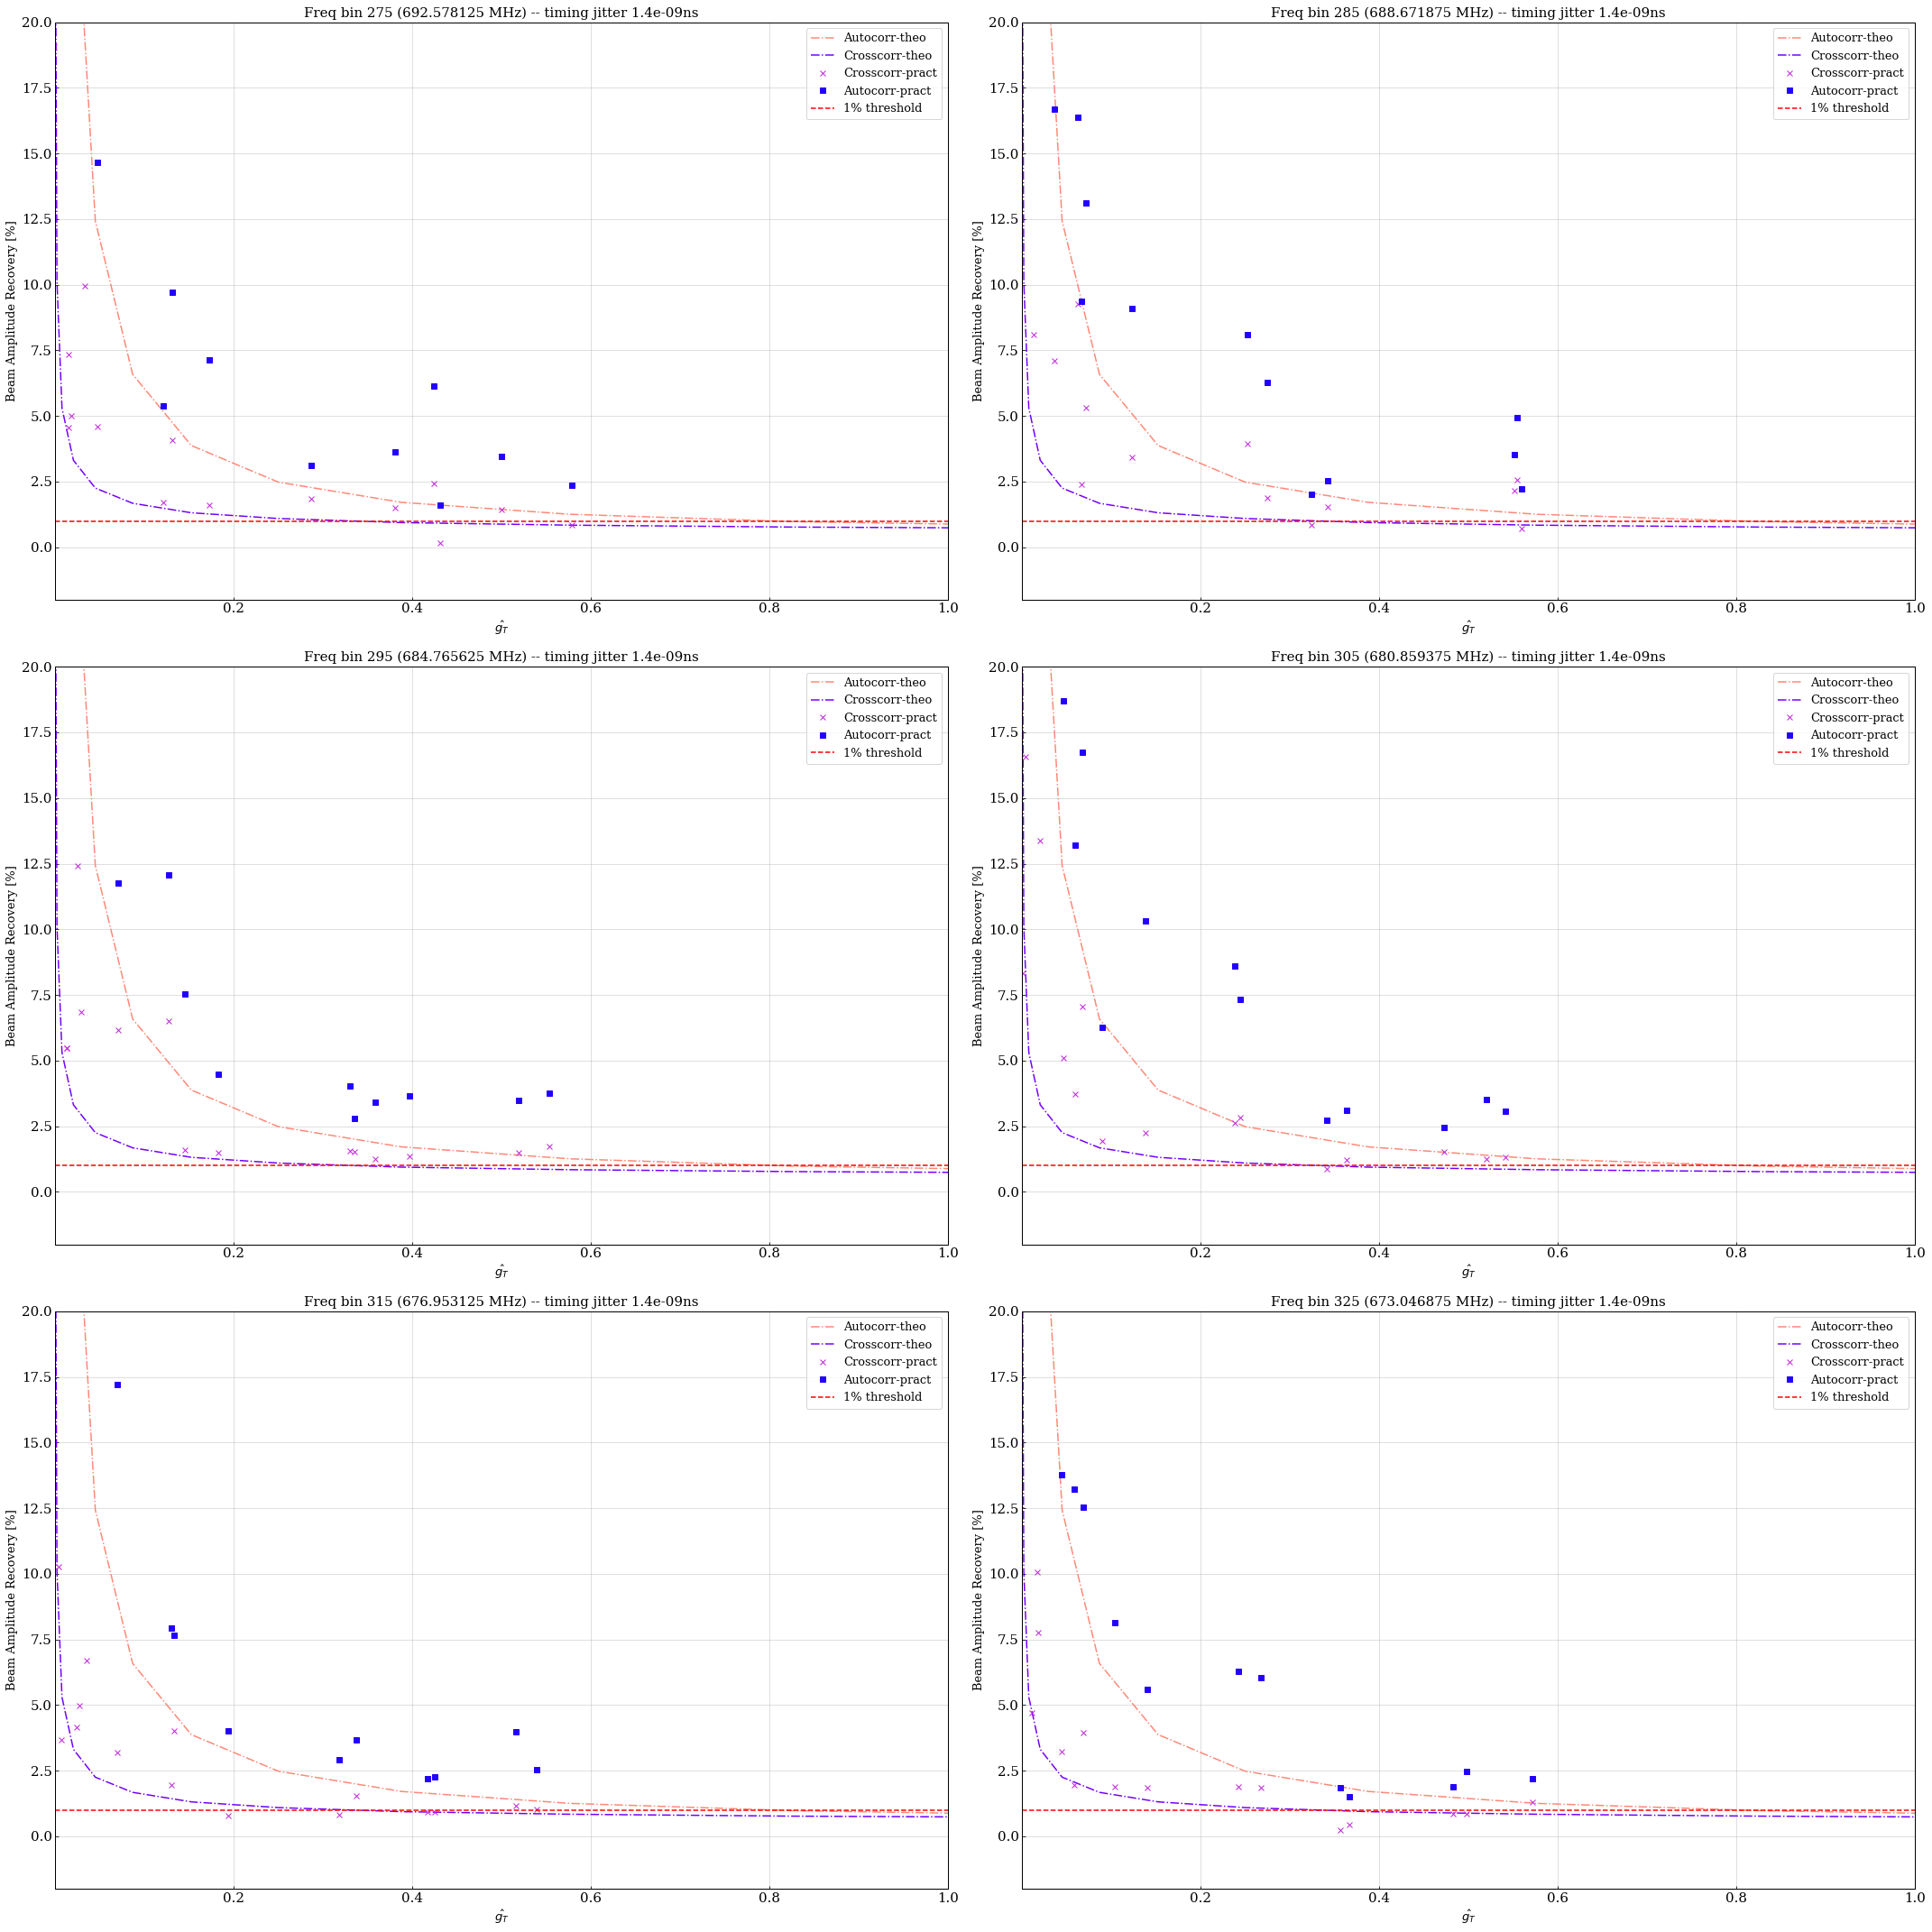

In [71]:
pcov_cross=beam_amp_recovery(freq_arr=[275,285,295,305,315,325])

In [12]:
## Do not run this now ## 
def beam_amp_recovery(freq_arr):
    """Function to plot beam amplitude recovery (%):
    
    Parameters
    ----------
    
    avgs: averages of ON data points of individual correlator channels 
    avgs_off: averages of OFF data points of individual correlator channels
    stds: standard deviations of ON data points of individual correlator channels
    var: variances of ON data points of individual correlator channels
    var_off: variances of OFF data points of individual correlator channels
    """
    
    colorsarr=cm.gnuplot2(np.linspace(0,1,1024))
    fig = plt.figure(figsize=[30,30])
    for index,f_ind in enumerate(freq_arr):
        
        avgs=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/stats_individual_pulses/means_fbin{}.npz".format(f_ind))
        avgs_off=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/stats_individual_pulses/means_off_fbin{}.npz".format(f_ind))
        stds=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/stats_individual_pulses/stds_fbin{}.npz".format(f_ind))
        var=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/stats_individual_pulses/var_fbin{}.npz".format(f_ind))
        var_off=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/stats_individual_pulses/var_off_fbin{}.npz".format(f_ind))

        """stats from saved files -- N 65536 (steps of 5 degrees) (range -130 t0 130)
        autos and crosses means, std dev and variances lists -- correlator data 
        
        Parameters
        ----------

        autos_0x0 -- <VV*>t,ON
        autos_0x0_off -- <VV*>t,OFF
        crosses_0x1 -- <VtVref*>ON
        autos_1x1 -- <VV*>ref,ON 
        autos_1x1_off -- <VV*>ref,OFF (which is 0 in this case) 
        """
        
        autos00 = [avgs['avgs130n'][0], avgs['avgs125n'][0], avgs['avgs120n'][0], avgs['avgs115n'][0], avgs['avgs110n'][0], avgs['avgs105n'][0], avgs['avgs100n'][0], avgs['avgs95n'][0], avgs['avgs90n'][0], avgs['avgs85n'][0], avgs['avgs80n'][0], avgs['avgs75n'][0], avgs['avgs70n'][0], avgs['avgs65n'][0], avgs['avgs60n'][0], avgs['avgs55n'][0], avgs['avgs50n'][0], avgs['avgs45n'][0], avgs['avgs40n'][0], avgs['avgs35n'][0], avgs['avgs30n'][0], avgs['avgs25n'][0], avgs['avgs20n'][0], avgs['avgs15n'][0], avgs['avgs10n'][0], avgs['avgs5n'][0], avgs['avgs0'][0], avgs['avgs5p'][0], avgs['avgs10p'][0], avgs['avgs15p'][0], avgs['avgs20p'][0], avgs['avgs25p'][0], avgs['avgs30p'][0], avgs['avgs35p'][0], avgs['avgs40p'][0], avgs['avgs45p'][0], avgs['avgs50p'][0], avgs['avgs55p'][0], avgs['avgs60p'][0], avgs['avgs65p'][0], avgs['avgs70p'][0], avgs['avgs75p'][0], avgs['avgs80p'][0], avgs['avgs85p'][0], avgs['avgs90p'][0], avgs['avgs95p'][0], avgs['avgs100p'][0], avgs['avgs105p'][0], avgs['avgs110p'][0], avgs['avgs115p'][0], avgs['avgs120p'][0], avgs['avgs125p'][0], avgs['avgs130p'][0]]
        autos11 = [avgs['avgs130n'][2], avgs['avgs125n'][2], avgs['avgs120n'][2], avgs['avgs115n'][2], avgs['avgs110n'][2], avgs['avgs105n'][2], avgs['avgs100n'][2], avgs['avgs95n'][2], avgs['avgs90n'][2], avgs['avgs85n'][2], avgs['avgs80n'][2], avgs['avgs75n'][2], avgs['avgs70n'][2], avgs['avgs65n'][2], avgs['avgs60n'][2], avgs['avgs55n'][2], avgs['avgs50n'][2], avgs['avgs45n'][2], avgs['avgs40n'][2], avgs['avgs35n'][2], avgs['avgs30n'][2], avgs['avgs25n'][2], avgs['avgs20n'][2], avgs['avgs15n'][2], avgs['avgs10n'][2], avgs['avgs5n'][2], avgs['avgs0'][2], avgs['avgs5p'][2], avgs['avgs10p'][2], avgs['avgs15p'][2], avgs['avgs20p'][2], avgs['avgs25p'][2], avgs['avgs30p'][2], avgs['avgs35p'][2], avgs['avgs40p'][2], avgs['avgs45p'][2], avgs['avgs50p'][2], avgs['avgs55p'][2], avgs['avgs60p'][2], avgs['avgs65p'][2], avgs['avgs70p'][2], avgs['avgs75p'][2], avgs['avgs80p'][2], avgs['avgs85p'][2], avgs['avgs90p'][2], avgs['avgs95p'][2], avgs['avgs100p'][2], avgs['avgs105p'][2], avgs['avgs110p'][2], avgs['avgs115p'][2], avgs['avgs120p'][2], avgs['avgs125p'][2], avgs['avgs130p'][2]]
        crosses01 = [avgs['avgs130n'][1], avgs['avgs125n'][1], avgs['avgs120n'][1], avgs['avgs115n'][1], avgs['avgs110n'][1], avgs['avgs105n'][1], avgs['avgs100n'][1], avgs['avgs95n'][1], avgs['avgs90n'][1], avgs['avgs85n'][1], avgs['avgs80n'][1], avgs['avgs75n'][1], avgs['avgs70n'][1], avgs['avgs65n'][1], avgs['avgs60n'][1], avgs['avgs55n'][1], avgs['avgs50n'][1], avgs['avgs45n'][1], avgs['avgs40n'][1], avgs['avgs35n'][1], avgs['avgs30n'][1], avgs['avgs25n'][1], avgs['avgs20n'][1], avgs['avgs15n'][1], avgs['avgs10n'][1], avgs['avgs5n'][1], avgs['avgs0'][1], avgs['avgs5p'][1], avgs['avgs10p'][1], avgs['avgs15p'][1], avgs['avgs20p'][1], avgs['avgs25p'][1], avgs['avgs30p'][1], avgs['avgs35p'][1], avgs['avgs40p'][1], avgs['avgs45p'][1], avgs['avgs50p'][1], avgs['avgs55p'][1], avgs['avgs60p'][1], avgs['avgs65p'][1], avgs['avgs70p'][1], avgs['avgs75p'][1], avgs['avgs80p'][1], avgs['avgs85p'][1], avgs['avgs90p'][1], avgs['avgs95p'][1], avgs['avgs100p'][1], avgs['avgs105p'][1], avgs['avgs110p'][1], avgs['avgs115p'][1], avgs['avgs120p'][1], avgs['avgs125p'][1], avgs['avgs130p'][1]]
        var_auto00 = [var['var130n'][0], var['var125n'][0], var['var120n'][0], var['var115n'][0], var['var110n'][0], var['var105n'][0], var['var100n'][0], var['var95n'][0], var['var90n'][0], var['var85n'][0], var['var80n'][0], var['var75n'][0], var['var70n'][0], var['var65n'][0], var['var60n'][0], var['var55n'][0], var['var50n'][0], var['var45n'][0], var['var40n'][0], var['var35n'][0], var['var30n'][0], var['var25n'][0], var['var20n'][0], var['var15n'][0], var['var10n'][0], var['var5n'][0], var['var0'][0], var['var5p'][0], var['var10p'][0], var['var15p'][0], var['var20p'][0], var['var25p'][0], var['var30p'][0], var['var35p'][0], var['var40p'][0], var['var45p'][0], var['var50p'][0], var['var55p'][0], var['var60p'][0], var['var65p'][0], var['var70p'][0], var['var75p'][0], var['var80p'][0], var['var85p'][0], var['var90p'][0], var['var95p'][0], var['var100p'][0], var['var105p'][0], var['var110p'][0], var['var115p'][0], var['var120p'][0], var['var125p'][0], var['var130p'][0]]
        var_auto11 = [var['var130n'][2], var['var125n'][2], var['var120n'][2], var['var115n'][2], var['var110n'][2], var['var105n'][2], var['var100n'][2], var['var95n'][2], var['var90n'][2], var['var85n'][2], var['var80n'][2], var['var75n'][2], var['var70n'][2], var['var65n'][2], var['var60n'][2], var['var55n'][2], var['var50n'][2], var['var45n'][2], var['var40n'][2], var['var35n'][2], var['var30n'][2], var['var25n'][2], var['var20n'][2], var['var15n'][2], var['var10n'][2], var['var5n'][2], var['var0'][2], var['var5p'][2], var['var10p'][2], var['var15p'][2], var['var20p'][2], var['var25p'][2], var['var30p'][2], var['var35p'][2], var['var40p'][2], var['var45p'][2], var['var50p'][2], var['var55p'][2], var['var60p'][2], var['var65p'][2], var['var70p'][2], var['var75p'][2], var['var80p'][2], var['var85p'][2], var['var90p'][2], var['var95p'][2], var['var100p'][2], var['var105p'][2], var['var110p'][2], var['var115p'][2], var['var120p'][2], var['var125p'][2], var['var130p'][2]]
        stddev_cross01 = [stds['stds130n'][1], stds['stds125n'][1], stds['stds120n'][1], stds['stds115n'][1], stds['stds110n'][1], stds['stds105n'][1], stds['stds100n'][1], stds['stds95n'][1], stds['stds90n'][1], stds['stds85n'][1], stds['stds80n'][1], stds['stds75n'][1], stds['stds70n'][1], stds['stds65n'][1], stds['stds60n'][1], stds['stds55n'][1], stds['stds50n'][1], stds['stds45n'][1], stds['stds40n'][1], stds['stds35n'][1], stds['stds30n'][1], stds['stds25n'][1], stds['stds20n'][1], stds['stds15n'][1], stds['stds10n'][1], stds['stds5n'][1], stds['stds0'][1], stds['stds5p'][1], stds['stds10p'][1], stds['stds15p'][1], stds['stds20p'][1], stds['stds25p'][1], stds['stds30p'][1], stds['stds35p'][1], stds['stds40p'][1], stds['stds45p'][1], stds['stds50p'][1], stds['stds55p'][1], stds['stds60p'][1], stds['stds65p'][1], stds['stds70p'][1], stds['stds75p'][1], stds['stds80p'][1], stds['stds85p'][1], stds['stds90p'][1], stds['stds95p'][1], stds['stds100p'][1], stds['stds105p'][1], stds['stds110p'][1], stds['stds115p'][1], stds['stds120p'][1], stds['stds125p'][1], stds['stds130p'][1]]
        
        
        autos_0x0 = []
        autos_1x1 = []
        crosses_0x1 = []
        var_auto0x0 = []
        var_auto1x1 = []
        stddev_cross = []

        for i, array in enumerate(autos00):
            for j in range(len(autos00[i])):
                autos_0x0.append(autos00[i][j])
                autos_1x1.append(autos11[i][j])
                crosses_0x1.append(crosses01[i][j])
                var_auto0x0.append(var_auto00[i][j])
                var_auto1x1.append(var_auto11[i][j])
                stddev_cross.append(stddev_cross01[i][j])
        
        autos00_off = [avgs_off['avgs_off130n'][0], avgs_off['avgs_off125n'][0], avgs_off['avgs_off120n'][0], avgs_off['avgs_off115n'][0], avgs_off['avgs_off110n'][0], avgs_off['avgs_off105n'][0], avgs_off['avgs_off100n'][0], avgs_off['avgs_off95n'][0], avgs_off['avgs_off90n'][0], avgs_off['avgs_off85n'][0], avgs_off['avgs_off80n'][0], avgs_off['avgs_off75n'][0], avgs_off['avgs_off70n'][0], avgs_off['avgs_off65n'][0], avgs_off['avgs_off60n'][0], avgs_off['avgs_off55n'][0], avgs_off['avgs_off50n'][0], avgs_off['avgs_off45n'][0], avgs_off['avgs_off40n'][0], avgs_off['avgs_off35n'][0], avgs_off['avgs_off30n'][0], avgs_off['avgs_off25n'][0], avgs_off['avgs_off20n'][0], avgs_off['avgs_off15n'][0], avgs_off['avgs_off10n'][0], avgs_off['avgs_off5n'][0], avgs_off['avgs_off0'][0], avgs_off['avgs_off5p'][0], avgs_off['avgs_off10p'][0], avgs_off['avgs_off15p'][0], avgs_off['avgs_off20p'][0], avgs_off['avgs_off25p'][0], avgs_off['avgs_off30p'][0], avgs_off['avgs_off35p'][0], avgs_off['avgs_off40p'][0], avgs_off['avgs_off45p'][0], avgs_off['avgs_off50p'][0], avgs_off['avgs_off55p'][0], avgs_off['avgs_off60p'][0], avgs_off['avgs_off65p'][0], avgs_off['avgs_off70p'][0], avgs_off['avgs_off75p'][0], avgs_off['avgs_off80p'][0], avgs_off['avgs_off85p'][0], avgs_off['avgs_off90p'][0], avgs_off['avgs_off95p'][0], avgs_off['avgs_off100p'][0], avgs_off['avgs_off105p'][0], avgs_off['avgs_off110p'][0], avgs_off['avgs_off115p'][0], avgs_off['avgs_off120p'][0], avgs_off['avgs_off125p'][0], avgs_off['avgs_off130p'][0]]
        autos_0x0_off = []

        for i, array in enumerate(autos00_off):
            for j in range(len(autos00_off[i])):
                autos_0x0_off.append(autos00_off[i][j])

        var_auto00_off = [var_off['var_off130n'][0], var_off['var_off125n'][0], var_off['var_off120n'][0], var_off['var_off115n'][0], var_off['var_off110n'][0], var_off['var_off105n'][0], var_off['var_off100n'][0], var_off['var_off95n'][0], var_off['var_off90n'][0], var_off['var_off85n'][0], var_off['var_off80n'][0], var_off['var_off75n'][0], var_off['var_off70n'][0], var_off['var_off65n'][0], var_off['var_off60n'][0], var_off['var_off55n'][0], var_off['var_off50n'][0], var_off['var_off45n'][0], var_off['var_off40n'][0], var_off['var_off35n'][0], var_off['var_off30n'][0], var_off['var_off25n'][0], var_off['var_off20n'][0], var_off['var_off15n'][0], var_off['var_off10n'][0], var_off['var_off5n'][0], var_off['var_off0'][0], var_off['var_off5p'][0], var_off['var_off10p'][0], var_off['var_off15p'][0], var_off['var_off20p'][0], var_off['var_off25p'][0], var_off['var_off30p'][0], var_off['var_off35p'][0], var_off['var_off40p'][0], var_off['var_off45p'][0], var_off['var_off50p'][0], var_off['var_off55p'][0], var_off['var_off60p'][0], var_off['var_off65p'][0], var_off['var_off70p'][0], var_off['var_off75p'][0], var_off['var_off80p'][0], var_off['var_off85p'][0], var_off['var_off90p'][0], var_off['var_off95p'][0], var_off['var_off100p'][0], var_off['var_off105p'][0], var_off['var_off110p'][0], var_off['var_off115p'][0], var_off['var_off120p'][0], var_off['var_off125p'][0], var_off['var_off130p'][0]]
        var_auto0x0_off = []

        for i, array in enumerate(var_auto00_off):
            for j in range(len(var_auto00_off[i])):
                var_auto0x0_off.append(var_auto00_off[i][j])
        #making all "off" stats arrays equal length: 
        var_auto0x0_off=var_auto0x0_off[:len(autos_0x0_off)]
        
        
        freq=400+((1024-f_ind)*0.390625) 
        #print('Given frequency: {}MHz'.format(freq))

        # converting into numpy ndarray for arithmatic operations -- N 65536
        """
            autos_0x0 -- <VV*>t,ON and # autos_1x1 -- <VV*>ref,ON 
        """
        
        autos_0x0_off=np.array(autos_0x0_off)
        autos_0x0_arr=np.array(autos_0x0)
        autos_0x0=autos_0x0_arr[:len(autos_0x0_off)]
        crosses_0x1_arr=np.array(crosses_0x1)
        crosses_0x1=crosses_0x1_arr[:len(autos_0x0_off)]
        autos_1x1_arr=np.array(autos_1x1)
        autos_1x1=autos_1x1_arr[:len(autos_0x0_off)]

        var_auto1x1_arr=np.array(var_auto1x1)
        var_auto1x1= var_auto1x1_arr[:len(autos_0x0_off)]
        var_auto0x0_arr=np.array(var_auto0x0)
        var_auto0x0= var_auto0x0_arr[:len(autos_0x0_off)]
        var_auto0x0_off_arr=np.array(var_auto0x0_off)
        var_auto0x0_off= var_auto0x0_off_arr[:len(autos_0x0_off)]
        
        stddev_cross_arr=np.array(stddev_cross)
        stddev_cross0x1= stddev_cross_arr[:len(autos_0x0_off)]

        # sqrt of total integration period -- N 65536
        stddev_cross0x1 = stddev_cross0x1/2 

        ## autos0x0 --  <VV*>t,ON - <VV*>t,OFF / <VV*>ref,ON - <VV*>ref,OFF -- N 65536 
        g_autos_0x0 = (autos_0x0 - autos_0x0_off) / autos_1x1

        ## error propagation equation -- to calculate variance and std dev of gauto0x0_2 -- N 65536 
        t11 = np.square(1/autos_1x1) 
        t21 = np.square(1/autos_1x1) 
        t31 = np.square((autos_0x0-autos_0x0_off)/(np.square(autos_1x1))) 

        t12=var_auto0x0 # var(on_index)
        t22=var_auto0x0_off # var(off_index) 
        t32=var_auto1x1 # var(on_index) 

        t1 = t11*t12
        t2 = t21*t22
        t3 = t31*t32

        var_gauto0x0= t1 + t2 + t3 
        stddev_gauto0x0=np.sqrt(var_gauto0x0)/2

        # error for crosses -- std/mean -- N 65536 
        err_crosses = []
        err_cross_percent = []
        for i in np.arange(0,np.size(stddev_cross0x1)):
            err = stddev_cross0x1[i]/crosses_0x1[i]
            err_crosses.append(err)
            err_percent = (stddev_cross0x1[i]/crosses_0x1[i])*100
            err_cross_percent.append(err_percent)

        # error for autos -- std/mean -- N 65536 
        err_autos = []
        err_auto_percent = []
        for i in np.arange(0,np.size(stddev_gauto0x0)):
            aerr = stddev_gauto0x0[i]/g_autos_0x0[i]
            err_autos.append(aerr)
            aerr_percent = (stddev_gauto0x0[i]/g_autos_0x0[i])*100
            err_auto_percent.append(aerr_percent)

        #gT= Scal/Tsys
        #Scal/Tsys=(Pon-Poff)/Poff
        g_T = (autos_0x0 - autos_0x0_off) / autos_0x0_off
        #print("total gain values are: {}".format(len(g_T)))
        #print('Telescopic gains are: {}'.format(g_T))

        ##dns simulations -- beam amp recovery in presence of noise 

        #Import a file -- loading saved data for (impact of noise) sims -- N 65536
        data=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/gain_sweep_10000.npz")
        #Assign the variables:
        gain_auto_quant= data['gain_auto_quant'] 
        gain_cross_quant= data['gain_cross_quant'] 
        gains= data['gains'] 
        ## Close the file:
        data.close()

        #Normalizing the data with gains -- N 65536
        int_time =4*16384 
        gain_auto_quant_std = (gain_auto_quant/(2*int_time*gains*gains)).std(axis=0)[:len(gains)]
        gain_cross_quant_std = (gain_cross_quant/(2*int_time*gains)).std(axis=0)[:len(gains)]
        gain_auto_qaunt_mean= (gain_auto_quant/(2*int_time*gains*gains)).mean(axis=0)[:len(gains)]
        gain_cross_quant_mean = (gain_cross_quant/(2*int_time*gains)).mean(axis=0)[:len(gains)]

        ##dns simulations -- beam amplitude recovery in presence of timing noise 

        fman=727e6 #select freq
        t_length=65536 # 4*16384
        inputpower=2**0 # this is 1
        iteration_space=np.arange(10000) # total 10000 realizations 
        jitter_space=np.hstack((np.array([0]),np.linspace(0.0e-9,1.4e-9,14))) # total 15 values 
        #jitter_space=np.hstack((np.array([0]),np.linspace(1.4e-9,2.1e-9,8))) # total 9 values
        gain_space=(np.linspace(0.05,1.2,15)**2.0) # total 30 values 

        #Import a file -- loading saved data for (imapact of timing jitter) sims -- N 65536
        dat=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/beam_amp_recovery_timing0-1.4ns_10000.npz")
        #Assign the variables:
        input_phase=dat['input_phase']
        q_sig_scaling=dat['q_sig_scaling']
        q_corr_scaling=dat['q_corr_scaling']
        nq_max_ind_auto=dat['nq_max_ind_auto']
        nq_max_mag_auto_on=dat['nq_max_mag_auto_on']
        nq_max_mag_auto_off=dat['nq_max_mag_auto_off']
        nq_max_ind_cross=dat['nq_max_ind_cross']
        nq_max_mag_cross_on=dat['nq_max_mag_cross_on']
        nq_max_mag_cross_off=dat['nq_max_mag_cross_off']
        q_max_ind_auto=dat['q_max_ind_auto']
        q_max_mag_auto_on=dat['q_max_mag_auto_on']
        q_max_mag_auto_off=dat['q_max_mag_auto_off']
        q_max_ind_cross=dat['q_max_ind_cross']
        q_max_mag_cross_on=dat['q_max_mag_cross_on']
        q_max_mag_cross_off=dat['q_max_mag_cross_off']
        #Close the file:
        dat.close()

        q_a_norm=np.zeros(q_max_mag_auto_on.shape) # normalization factor for autos 
        q_c_norm=np.zeros(q_max_mag_auto_on.shape) # normalization factor for crosses 
        for j in range(len(jitter_space)):
            q_a_norm[j,:,:]=(1.0/(2*(inputpower**2.0)*(q_corr_scaling[j,:,:]**2.0)*(t_length)*(np.outer((gain_space[:]**2.0),np.ones(len(iteration_space))))))
            q_c_norm[j,:,:]=(1.0/(2*(inputpower**2.0)*q_corr_scaling[j,:,:]*q_sig_scaling[j,:,:]*(t_length)*(np.outer((gain_space[:]**1.0),np.ones(len(iteration_space))))))

        # q_x -- error on autos; q_y -- error on crosses; q_z -- error on phase 
        q_x=100.0*np.nanstd((np.abs(q_a_norm*q_max_mag_auto_on[:,:,:])-np.abs(q_a_norm*q_max_mag_auto_off[:,:,:])),axis=2)/np.nanmean((np.abs(q_a_norm*q_max_mag_auto_on[:,:,:])-np.abs(q_a_norm*q_max_mag_auto_off[:,:,:])),axis=2)
        q_y=100.0*np.nanstd(np.abs(q_c_norm*q_max_mag_cross_on[:,:,:]),axis=2)/np.nanmean(np.abs(q_c_norm*q_max_mag_cross_on[:,:,:]),axis=2)
        q_z=100.0*np.nanstd(-np.angle(nq_max_mag_cross_on[:,:,:]),axis=2)/(2.0*np.pi)

        #print('jitter space is given as: {}'.format(jitter_space))

        #Plot of 10000 realizations used for DNS paper along with implementation results -- beam amplitude recovery (%)
        dim1 = math.floor(math.sqrt(len(freq_arr)))
        dim2 = math.ceil(len(freq_arr)/dim1)
        ax = plt.subplot(dim2,dim1,index+1)
        ax.plot(gain_space*gain_space,q_x[9,:],linestyle= 'dashdot',c=colorsarr[700],label='Autocorr-theo')
        ax.plot(gain_space*gain_space,q_y[9,:],linestyle= 'dashdot',c=colorsarr[400],label='Crosscorr-theo')
        ax.plot(g_T[:], err_cross_percent[:], 'x', c=colorsarr[500], label='Crosscorr-pract')
        ax.plot(g_T[:], err_auto_percent[:], 's', c=colorsarr[300], label='Autocorr-pract')
        plt.xlabel('$\hat{g_T}$', fontsize= 13) 
        plt.ylabel('Beam Amplitude Recovery [%]', fontsize= 13) 
        plt.axhline(y = 1, color = 'r', linestyle = '--', label= "1% threshold")
        #plt.axvline(x = 0.558, c=colorsarr[50], ymin=0.0, ymax=0.1, linestyle = '--')
        #plt.axvline(x = 0.665, c=colorsarr[50], ymin=0.0, ymax=0.1, linestyle = '--')
        
        #performing fit on beam amp recovery errors: 
        bounds = ([0,0], [np.inf, np.inf])
        initial_params_crosses = [10,15]
        initial_params_autos = [1,0.001]
        popt_cross, pcov_cross = curve_fit(fit_, g_T[:], err_cross_percent[:], p0=initial_params_crosses, bounds=bounds, nan_policy='omit')
        popt_auto, pcov_auto = curve_fit(fit_, g_T[:], err_auto_percent[:], p0=initial_params_autos, bounds=bounds, nan_policy='omit')
    
        #Extracting fitted parameters:
        A_fit_cross, k_fit_cross = popt_cross
        A_fit_auto, k_fit_auto = popt_auto
        print(f"Fitted parameters for crosses: A = {A_fit_cross:.3f}, k = {k_fit_cross:.3f}")
        print(f"Fitted parameters for autos: A = {A_fit_auto:.3f}, k = {k_fit_auto:.3f}")
        x_fit = g_T[:]
        y_fit_cross = fit_(x_fit, *popt_cross)
        y_fit_auto = fit_(x_fit, *popt_auto)
        ax.plot(x_fit, y_fit_cross,'*',c=colorsarr[100], label="Fitted curve for crosses")
        #ax.plot(x_fit, y_fit_auto,'*',c=colorsarr[200], label="Fitted curve for autos")
        
        plt.grid(True)
        ax.legend(fontsize= 13)
        plt.ylim(-2,20)
        plt.xlim(0.00025,1)
        #plt.suptitle("Main beam amplitude recovery", fontsize=40)
        plt.title(f"Freq bin {f_ind} ({freq} MHz) -- timing jitter {jitter_space[9]}ns", fontsize=15)
    plt.tight_layout()
    return pcov_cross


Fitted parameters for crosses: A = 0.569, k = 0.064
Fitted parameters for autos: A = 0.252, k = 0.001
Fitted parameters for crosses: A = 0.616, k = 0.070
Fitted parameters for autos: A = 0.000, k = 0.001
Fitted parameters for crosses: A = 0.526, k = 0.056
Fitted parameters for autos: A = 0.000, k = 0.001
Fitted parameters for crosses: A = 0.560, k = 0.059
Fitted parameters for autos: A = 0.002, k = 0.001
Fitted parameters for crosses: A = 0.537, k = 0.058
Fitted parameters for autos: A = 0.402, k = 0.001
Fitted parameters for crosses: A = 0.597, k = 0.067
Fitted parameters for autos: A = 0.101, k = 0.001
Fitted parameters for crosses: A = 0.576, k = 0.063
Fitted parameters for autos: A = 0.001, k = 0.001
Fitted parameters for crosses: A = 0.631, k = 0.070
Fitted parameters for autos: A = 0.081, k = 0.001
Fitted parameters for crosses: A = 0.569, k = 0.061
Fitted parameters for autos: A = 0.000, k = 0.001
Fitted parameters for crosses: A = 0.762, k = 0.086
Fitted parameters for autos: A

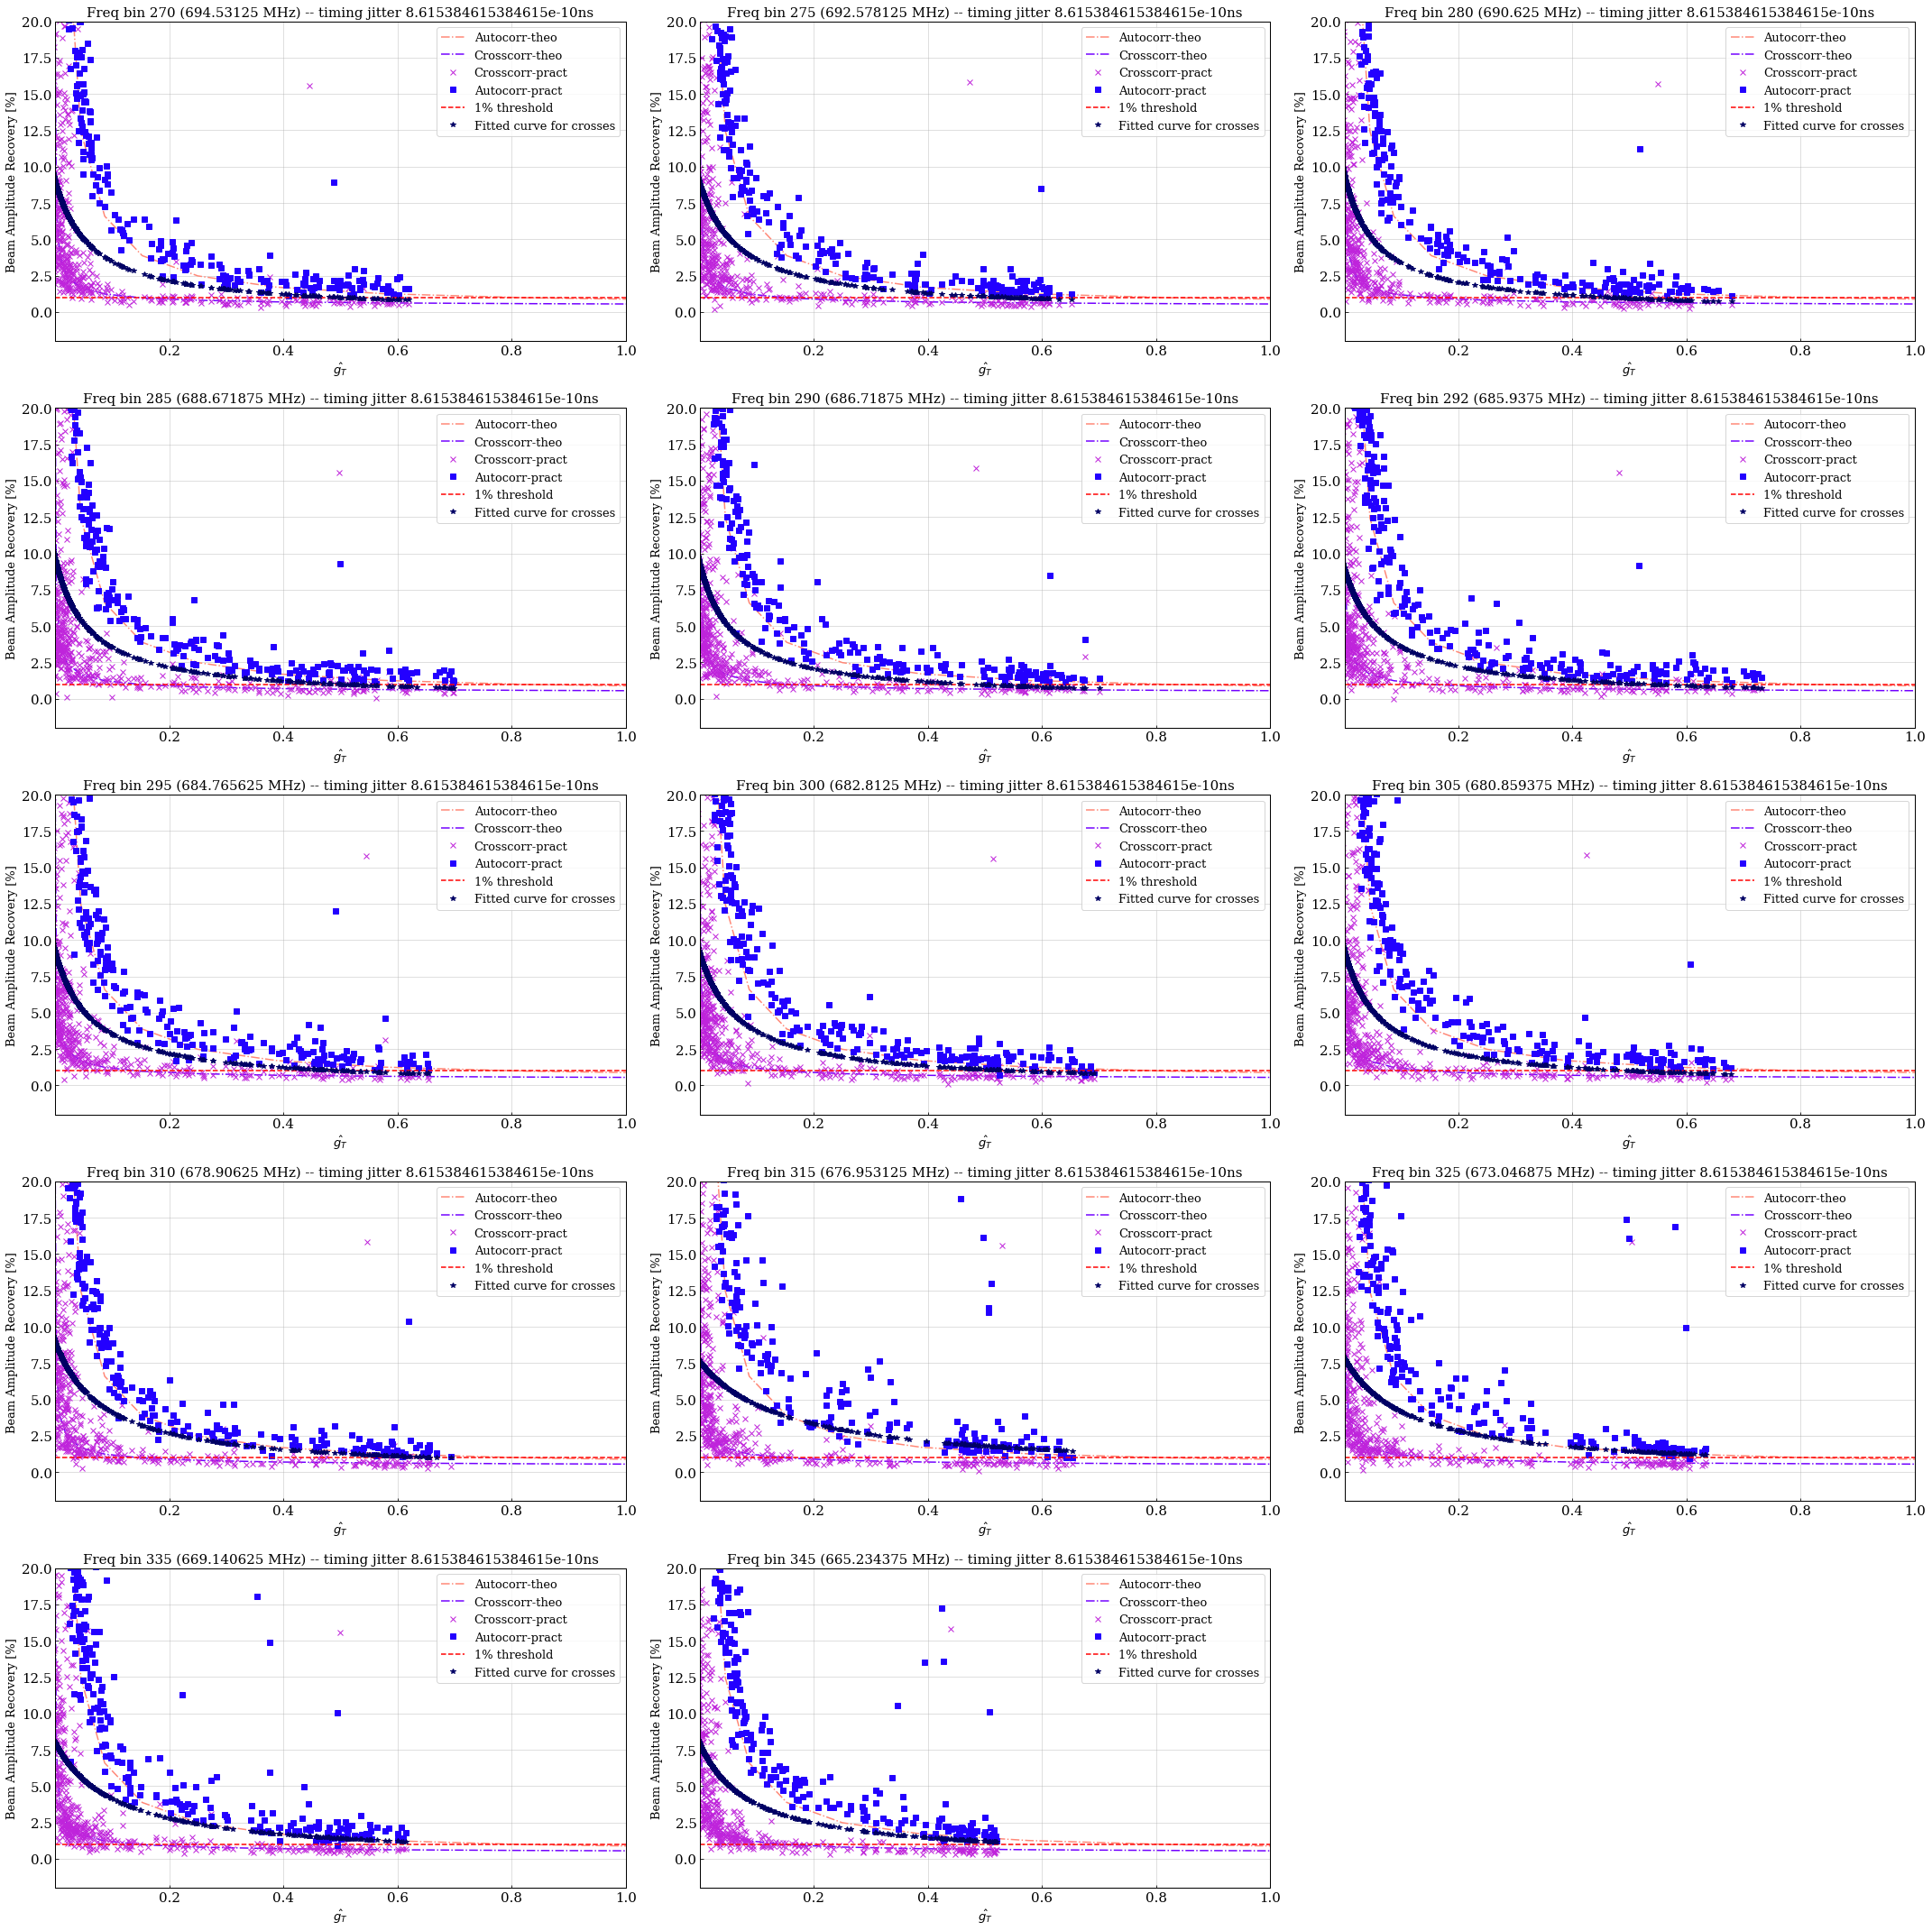

In [13]:
pcov_cross=beam_amp_recovery(freq_arr=[270,275,280,285,290,292,295,300,305,310,315,325,335,345])

In [ ]:
""" Trial for fitting """
from numpy import array
from scipy.optimize import leastsq
import matplotlib.pyplot as plt 

y=array([12,8,11,7,5,2,3,5,6,4,5,7,8,13,19,22,25]) ##err_cross_percent
x=array(range(len(y))) ##g_T
print(x)
print(y)

def func(params,x,y): ##scale_factor,g_T,err_cross_percent
    a,b,c=params[0], params[1], params[2] ## none 
    residual= y - (a*x**2+b*x+c) ## err_cross_percent - a*np.exp(-g_T)
    return residual 

params=[0,0,0]
# param = 1.083
result=leastsq(func, params, (x,y))
a,b,c= result[0][0], result[0][1], result[0][2] #a=result[0]
yfit1=a*x**2+b*x+c #a*np.exp(g_T)

plt.plot(x,y,'bo', label='y-original')
plt.plot(x,yfit1,'--', label='y-fit')
plt.legend()



In [66]:
def plot_telescopic_gains(freq_arr):
    """Plot beam amplitude recovery (%) of the receiver system.
    
    Parameters
    ----------
    
    avgs: averages of ON data points of individual correlator channel 
    avgs_off: averages of OFF data points of individual correlator channel
    g_T: Telescopic gain corresponding to beam angles
    
    """
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    fig = plt.figure(figsize=[20,20])
    for index,f_ind in enumerate(freq_arr):
        
        avgs=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/stats_individual_pulses/means_fbin{}.npz".format(f_ind))
        avgs_off=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/stats_individual_pulses/means_off_fbin{}.npz".format(f_ind))
        
        """stats from saved files -- N 65536 (steps of 5 degrees) (range -130 to 130)
        autos and crosses means, std dev and variances lists-- correlator data 
        
        Parameters
        ----------

        autos_0x0 -- <VV*>t,ON
        autos_0x0_off -- <VV*>t,OFF
        """
        
        #autos00 = [avgs['avgs130n'][0], avgs['avgs125n'][0], avgs['avgs120n'][0], avgs['avgs115n'][0], avgs['avgs110n'][0], avgs['avgs105n'][0], avgs['avgs100n'][0], avgs['avgs95n'][0], avgs['avgs90n'][0], avgs['avgs85n'][0], avgs['avgs80n'][0], avgs['avgs75n'][0], avgs['avgs70n'][0], avgs['avgs65n'][0], avgs['avgs60n'][0], avgs['avgs55n'][0], avgs['avgs50n'][0], avgs['avgs45n'][0], avgs['avgs40n'][0], avgs['avgs35n'][0], avgs['avgs30n'][0], avgs['avgs25n'][0], avgs['avgs20n'][0], avgs['avgs15n'][0], avgs['avgs10n'][0], avgs['avgs5n'][0], avgs['avgs0'][0], avgs['avgs5p'][0], avgs['avgs10p'][0], avgs['avgs15p'][0], avgs['avgs20p'][0], avgs['avgs25p'][0], avgs['avgs30p'][0], avgs['avgs35p'][0], avgs['avgs40p'][0], avgs['avgs45p'][0], avgs['avgs50p'][0], avgs['avgs55p'][0], avgs['avgs60p'][0], avgs['avgs65p'][0], avgs['avgs70p'][0], avgs['avgs75p'][0], avgs['avgs80p'][0], avgs['avgs85p'][0], avgs['avgs90p'][0], avgs['avgs95p'][0], avgs['avgs100p'][0], avgs['avgs105p'][0], avgs['avgs110p'][0], avgs['avgs115p'][0], avgs['avgs120p'][0], avgs['avgs125p'][0], avgs['avgs130p'][0]]
        #autos00_off = [avgs_off['avgs_off130n'][0], avgs_off['avgs_off125n'][0], avgs_off['avgs_off120n'][0], avgs_off['avgs_off115n'][0], avgs_off['avgs_off110n'][0], avgs_off['avgs_off105n'][0], avgs_off['avgs_off100n'][0], avgs_off['avgs_off95n'][0], avgs_off['avgs_off90n'][0], avgs_off['avgs_off85n'][0], avgs_off['avgs_off80n'][0], avgs_off['avgs_off75n'][0], avgs_off['avgs_off70n'][0], avgs_off['avgs_off65n'][0], avgs_off['avgs_off60n'][0], avgs_off['avgs_off55n'][0], avgs_off['avgs_off50n'][0], avgs_off['avgs_off45n'][0], avgs_off['avgs_off40n'][0], avgs_off['avgs_off35n'][0], avgs_off['avgs_off30n'][0], avgs_off['avgs_off25n'][0], avgs_off['avgs_off20n'][0], avgs_off['avgs_off15n'][0], avgs_off['avgs_off10n'][0], avgs_off['avgs_off5n'][0], avgs_off['avgs_off0'][0], avgs_off['avgs_off5p'][0], avgs_off['avgs_off10p'][0], avgs_off['avgs_off15p'][0], avgs_off['avgs_off20p'][0], avgs_off['avgs_off25p'][0], avgs_off['avgs_off30p'][0], avgs_off['avgs_off35p'][0], avgs_off['avgs_off40p'][0], avgs_off['avgs_off45p'][0], avgs_off['avgs_off50p'][0], avgs_off['avgs_off55p'][0], avgs_off['avgs_off60p'][0], avgs_off['avgs_off65p'][0], avgs_off['avgs_off70p'][0], avgs_off['avgs_off75p'][0], avgs_off['avgs_off80p'][0], avgs_off['avgs_off85p'][0], avgs_off['avgs_off90p'][0], avgs_off['avgs_off95p'][0], avgs_off['avgs_off100p'][0], avgs_off['avgs_off105p'][0], avgs_off['avgs_off110p'][0], avgs_off['avgs_off115p'][0], avgs_off['avgs_off120p'][0], avgs_off['avgs_off125p'][0], avgs_off['avgs_off130p'][0]]
        autos00 = [avgs['avgs10n'][0], avgs['avgs5n'][0], avgs['avgs0'][0], avgs['avgs5p'][0], avgs['avgs10p'][0]]
        autos00_off = [avgs_off['avgs_off10n'][0], avgs_off['avgs_off5n'][0], avgs_off['avgs_off0'][0], avgs_off['avgs_off5p'][0], avgs_off['avgs_off10p'][0]]
        autos_0x0 = []
        autos_0x0_off = []
        for i, array in enumerate(autos00):
            for j in range(len(autos00[i])):
                autos_0x0.append(autos00[i][j])
        
        for i, array in enumerate(autos00_off):
            for j in range(len(autos00_off[i])):
                autos_0x0_off.append(autos00_off[i][j])
        
        # converting into numpy ndarray for arithmatic operations -- N 65536
        autos_0x0_off=np.array(autos_0x0_off)
        autos_0x0_arr=np.array(autos_0x0)
        autos_0x0=autos_0x0_arr[:len(autos_0x0_off)]
        
        freq=400+((1024-f_ind)*0.390625)
        print('Given frequency: {}MHz'.format(freq))
        
        #gT= Scal/Tsys= (Pon-Poff)/Poff
        g_T = (autos_0x0 - autos_0x0_off) / autos_0x0_off
        #print("total gain values are: {}".format(len(g_T)))
        #print('Telescopic gains are: {}'.format(g_T))
        #plotting telescopic gains against angles 
        dim1 = math.floor(math.sqrt(len(freq_arr)))
        dim2 = math.ceil(len(freq_arr)/dim1)
        ax = plt.subplot(dim2,dim1,index+1)
        #angles = np.arange(-40,150,5) for chamber data
        angles_off=np.arange(0,54,1)
        ax.plot(angles_off,g_T,'x', c=colorsarr[f_ind+600])
        #plt.xlabel('$\phi$ [degrees] ')
        plt.xlabel('#samples')
        plt.ylabel('$\hat{g_T}$')
        plt.title(f'freq bin {f_ind} i.e. {freq} MHz')
        plt.suptitle(f'Telescopic gains')
    plt.tight_layout()
        

Given frequency: 692.578125MHz
Given frequency: 688.671875MHz
Given frequency: 684.765625MHz
Given frequency: 680.859375MHz
Given frequency: 676.953125MHz
Given frequency: 673.046875MHz


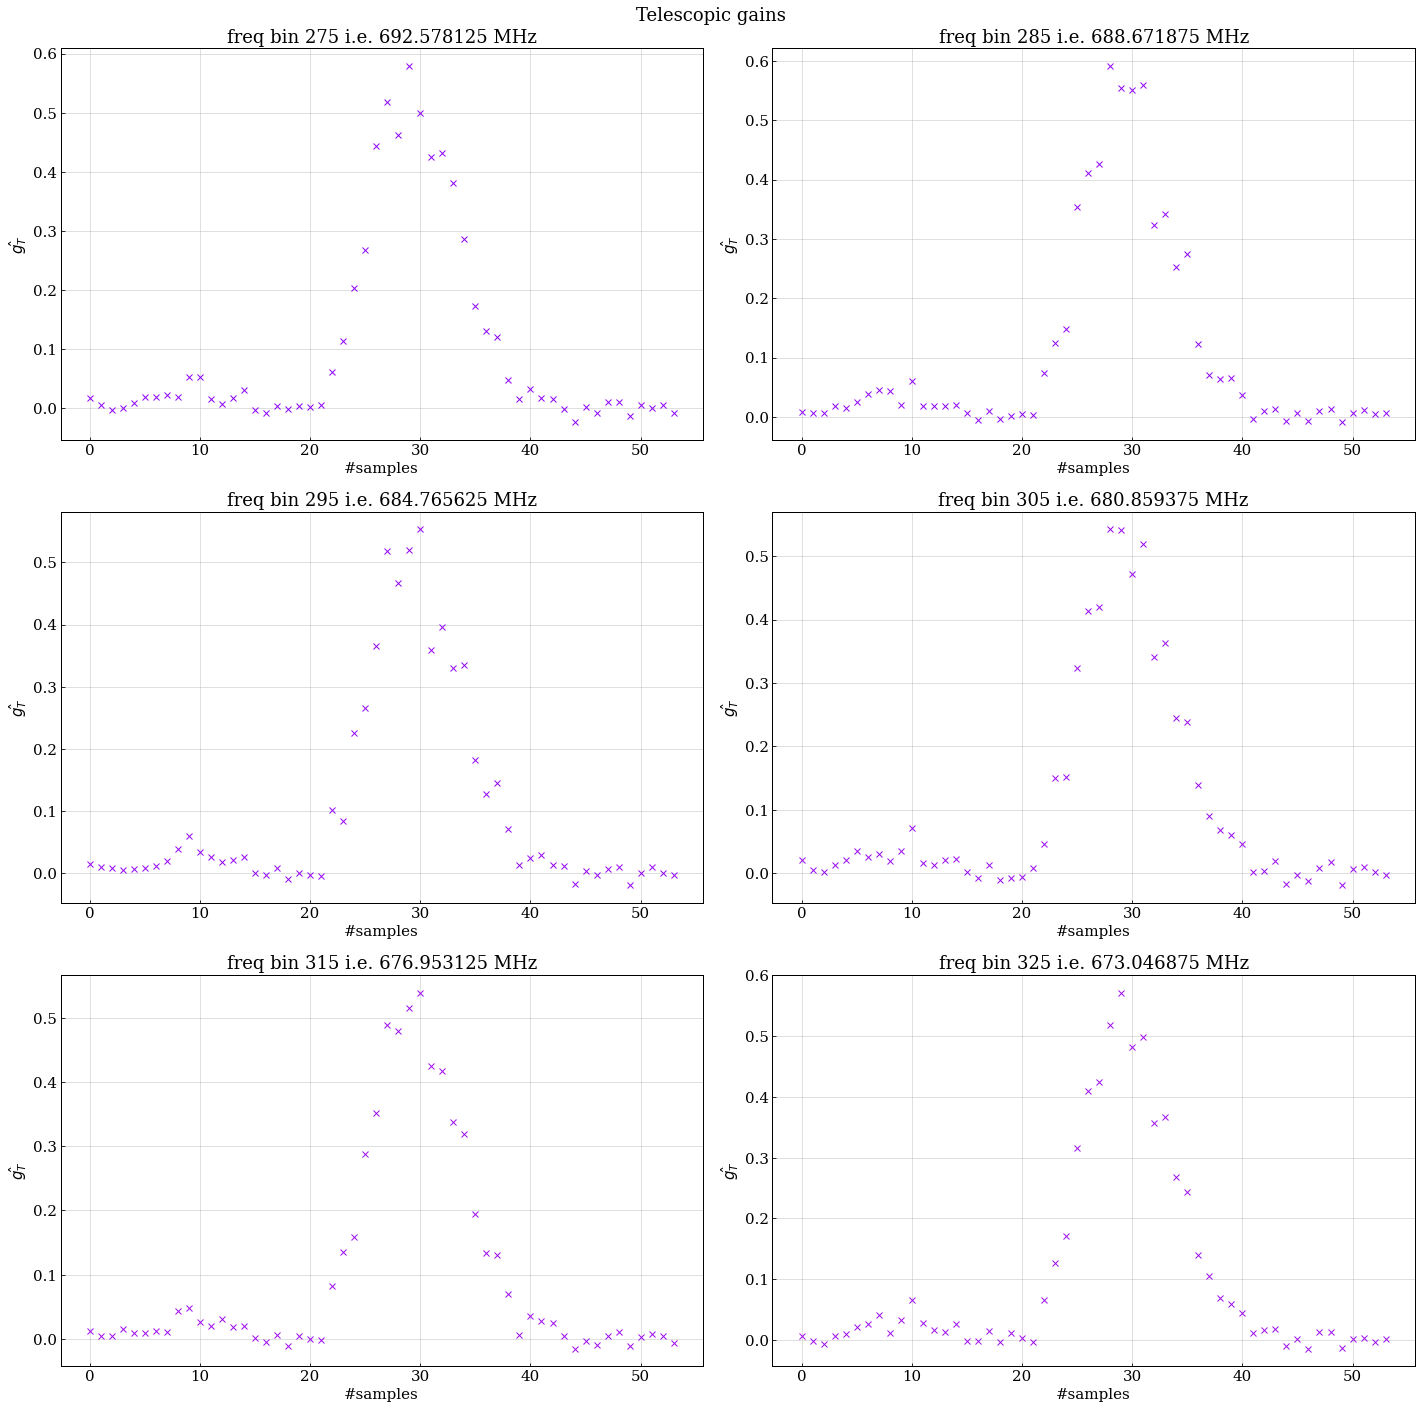

In [67]:
plot_telescopic_gains(freq_arr=[275,285,295,305,315,325])

In [ ]:
 pcov_cross

In [ ]:
perr = np.sqrt(np.diag( pcov_cross))

In [ ]:
perr

In [ ]:
20 / np.exp(-1 * 0)